# Testing Time Horizons and Constructing Lagged Features

This notebook guides you through testing different prediction horizons (5 days, 20 days ahead) and constructing lagged features for regime classification.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Regime Classification Data

Load the rule-based regime labels from the previous analysis.

In [2]:
# Load the data from rule-based regime segmentation
data_path = Path('../../../data/master_data.csv')
df = pd.read_csv(data_path)

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

price_col = 'GSPC'
ret_col = 'Return'

# Calculate SMAs for regime classification
df['SMA_50'] = df[price_col].rolling(window=50).mean()
df['SMA_200'] = df[price_col].rolling(window=200).mean()
df['Roll_Vol_21d'] = df[ret_col].rolling(window=21).std()

print(f"Data loaded. Shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
df.head()

Data loaded. Shape: (8066, 30)
Date range: 1994-01-27 00:00:00 to 2026-02-13 00:00:00


,Date,GSPC,VIX,SPY Volume,GDP,Core_Inflation,Unemployment,M2,Return,Return_5d,...,Core_Inflation_YoY,M2_YoY,Peak,Drawdown,VIX_Change,VIX_Change_5d,Regime,SMA_50,SMA_200,Roll_Vol_21d
0,1994-01-27,477.049988,10.30,344500,10939.116,66.902,6.6,3474.9,0.008136,0.004358,...,0.022466,0.016320,477.049988,0.000000,-0.870000,-0.860000,NaN,NaN,NaN,NaN
1,1994-01-28,478.700012,9.94,356500,10939.116,66.902,6.6,3474.9,0.003459,0.008384,...,0.020516,0.017689,478.700012,0.000000,-0.360001,-1.150001,NaN,NaN,NaN,NaN
2,1994-01-31,481.609985,10.63,313800,10939.116,66.902,6.6,3474.9,0.006079,0.020425,...,0.020516,0.017689,481.609985,0.000000,0.690001,-0.970000,NaN,NaN,NaN,NaN
3,1994-02-01,479.619995,10.65,303600,10939.116,67.047,6.6,3475.7,-0.004132,0.018474,...,0.022728,0.017924,481.609985,-0.004132,0.020000,-0.730000,NaN,NaN,NaN,NaN
4,1994-02-02,482.000000,10.61,307600,10939.116,67.047,6.6,3475.7,0.004962,0.018597,...,0.022728,0.017924,482.000000,0.000000,-0.040000,-0.560000,NaN,NaN,NaN,NaN


## 3. Define Time Horizons

Set up different prediction horizons to test. We'll evaluate predictions at 5 days, 10 days, and 20 days ahead.

In [3]:
# Define time horizons (in days)
HORIZONS = [5, 10, 20]

print(f"Testing 05_prediction horizons: {HORIZONS} days ahead")
print("\nFor each horizon, we will:")
print("1. Create a target variable by shifting the regime forward by N days")
print("2. Create lagged features from historical data")
print("3. Evaluate 05_prediction accuracy for each horizon")

Testing prediction horizons: [5, 10, 20] days ahead

For each horizon, we will:
1. Create a target variable by shifting the regime forward by N days
2. Create lagged features from historical data
3. Evaluate prediction accuracy for each horizon


## 4. Construct Lagged Features

Create lagged features from historical regime classifications and price data.

In [4]:
# Create current regime classification (bull/bear)
df['regime'] = np.where(df['SMA_50'] > df['SMA_200'], 'bull', 'bear')

# Create lagged features
LAG_PERIODS = [1, 5, 10, 21]  # Lags in days

# Lagged regime features
for lag in LAG_PERIODS:
    df[f'regime_lag_{lag}'] = df['regime'].shift(lag)
    # Convert to numeric: bull=1, bear=0
    df[f'regime_lag_{lag}_numeric'] = (df[f'regime_lag_{lag}'] == 'bull').astype(int)

# Lagged returns
for lag in LAG_PERIODS:
    df[f'return_lag_{lag}'] = df[ret_col].shift(lag)

# Lagged volatility
for lag in LAG_PERIODS:
    df[f'volatility_lag_{lag}'] = df['Roll_Vol_21d'].shift(lag)

# SMA ratio (50/200) as a feature
df['sma_ratio'] = df['SMA_50'] / df['SMA_200']
df['sma_ratio_lag_1'] = df['sma_ratio'].shift(1)

print(f"Created lagged features with lags: {LAG_PERIODS}")
print(f"\nFeature columns created:")
feature_cols = [col for col in df.columns if 'lag' in col.lower() or 'sma_ratio' in col]
for col in feature_cols:
    print(f"  - {col}")

print(f"\nTotal columns: {df.shape[1]}")

Created lagged features with lags: [1, 5, 10, 21]

Feature columns created:
  - regime_lag_1
  - regime_lag_1_numeric
  - regime_lag_5
  - regime_lag_5_numeric
  - regime_lag_10
  - regime_lag_10_numeric
  - regime_lag_21
  - regime_lag_21_numeric
  - return_lag_1
  - return_lag_5
  - return_lag_10
  - return_lag_21
  - volatility_lag_1
  - volatility_lag_5
  - volatility_lag_10
  - volatility_lag_21
  - sma_ratio
  - sma_ratio_lag_1

Total columns: 49


## 5. Create Target Variables for Different Horizons

Generate target variables for each time horizon by shifting the regime labels forward.

In [5]:
# Create target variables for each horizon
for horizon in HORIZONS:
    # Shift regime forward (future values)
    df[f'regime_target_{horizon}d'] = df['regime'].shift(-horizon)
    df[f'regime_target_{horizon}d_numeric'] = (df[f'regime_target_{horizon}d'] == 'bull').astype(int)

print("Target variables created for each horizon:")
for horizon in HORIZONS:
    print(f"\n  Horizon: {horizon} days ahead")
    target_col = f'regime_target_{horizon}d'
    valid_count = df[target_col].notna().sum()
    print(f"    - Valid samples: {valid_count}")
    print(f"    - Bull regimes: {(df[target_col] == 'bull').sum()}")
    print(f"    - Bear regimes: {(df[target_col] == 'bear').sum()}")

Target variables created for each horizon:

  Horizon: 5 days ahead
    - Valid samples: 8061
    - Bull regimes: 5938
    - Bear regimes: 2123

  Horizon: 10 days ahead
    - Valid samples: 8056
    - Bull regimes: 5938
    - Bear regimes: 2118

  Horizon: 20 days ahead
    - Valid samples: 8046
    - Bull regimes: 5938
    - Bear regimes: 2108


## 6. Evaluate Regime Predictions Across Horizons

Test your rule-based classification logic against each time horizon target variable.

In [6]:
# Store evaluation results_gmm
results = []

for horizon in HORIZONS:
    target_col = f'regime_target_{horizon}d'
    target_numeric_col = f'regime_target_{horizon}d_numeric'
    
    # Create predictions (current regime as 05_prediction for future regime)
    df[f'regime_pred_{horizon}d'] = df['regime']
    df[f'regime_pred_{horizon}d_numeric'] = (df['regime'] == 'bull').astype(int)
    
    # Drop rows with NaN values in target or 05_prediction
    valid_mask = df[target_col].notna() & df[f'regime_pred_{horizon}d'].notna()
    valid_data = df[valid_mask]
    
    if len(valid_data) > 0:
        y_true = valid_data[target_numeric_col].values
        y_pred = valid_data[f'regime_pred_{horizon}d_numeric'].values
        
        # Calculate metrics
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        
        results.append({
            'Horizon (days)': horizon,
            'Samples': len(valid_data),
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1
        })
        
        print(f"\n{'='*60}")
        print(f"Horizon: {horizon} days ahead")
        print(f"{'='*60}")
        print(f"Valid samples: {len(valid_data)}")
        print(f"Accuracy:  {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall:    {recall:.4f}")
        print(f"F1-Score:  {f1:.4f}")

results_df = pd.DataFrame(results)
print(f"\n{'='*60}")
print("Summary of Results:")
print(f"{'='*60}")
print(results_df.to_string(index=False))


Horizon: 5 days ahead
Valid samples: 8061
Accuracy:  0.9820
Precision: 0.9882
Recall:    0.9874
F1-Score:  0.9878

Horizon: 10 days ahead
Valid samples: 8056
Accuracy:  0.9652
Precision: 0.9772
Recall:    0.9756
F1-Score:  0.9764

Horizon: 20 days ahead
Valid samples: 8046
Accuracy:  0.9334
Precision: 0.9564
Recall:    0.9532
F1-Score:  0.9548

Summary of Results:
 Horizon (days)  Samples  Accuracy  Precision   Recall  F1-Score
              5     8061  0.982012   0.988202 0.987369  0.987785
             10     8056  0.965243   0.977227 0.975581  0.976403
             20     8046  0.933383   0.956404 0.953183  0.954791


## 7. Compare Performance Metrics by Time Horizon

Visualize and compare performance metrics across different time horizons.

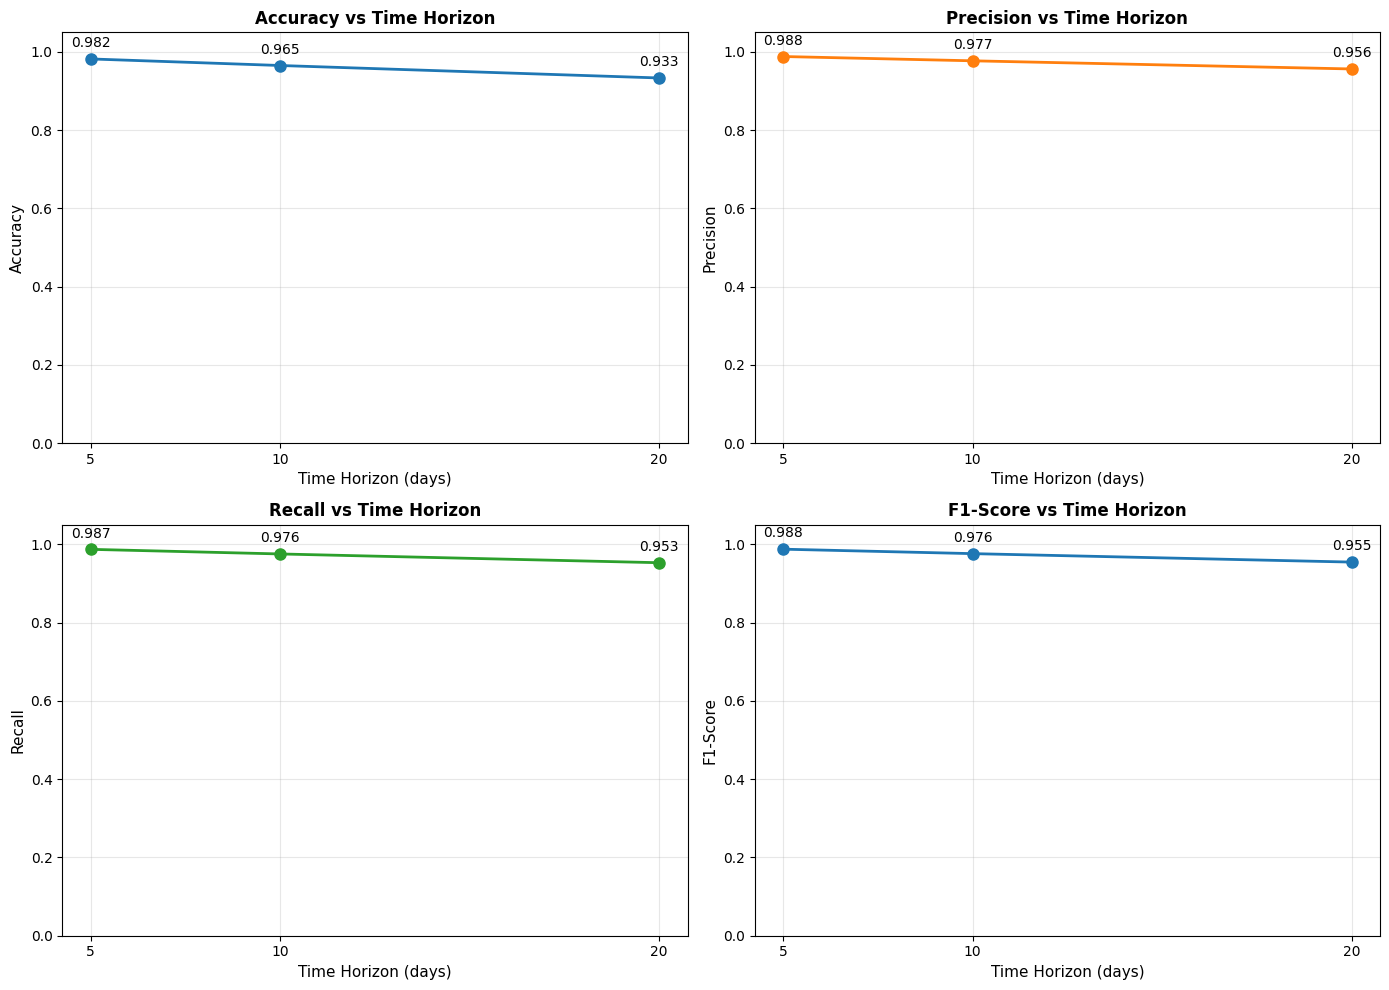


Visualization saved to: ../../reports/horizon_comparison.png


In [8]:
# Create comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    ax.plot(results_df['Horizon (days)'], results_df[metric], marker='o', linewidth=2, markersize=8, color=colors[idx % 3])
    ax.set_xlabel('Time Horizon (days)', fontsize=11)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(f'{metric} vs Time Horizon', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(results_df['Horizon (days)'])
    ax.set_ylim([0, 1.05])
    
    # Add value labels on points
    for x, y in zip(results_df['Horizon (days)'], results_df[metric]):
        ax.text(x, y + 0.03, f'{y:.3f}', ha='center', fontsize=10)

plt.tight_layout()
# plt.savefig('../../reports/horizon_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization saved to: ../../reports/horizon_comparison.png")

## 8. Key Insights and Recommendations

Based on the results above, consider the following when choosing a time horizon:

In [9]:
# Find best performing horizon for each metric
print("\n" + "="*70)
print("RECOMMENDATIONS FOR OPTIMAL TIME HORIZON")
print("="*70)

best_accuracy_idx = results_df['Accuracy'].idxmax()
best_f1_idx = results_df['F1-Score'].idxmax()
best_recall_idx = results_df['Recall'].idxmax()

print(f"\n✓ Best Accuracy: {results_df.loc[best_accuracy_idx, 'Horizon (days)']} days")
print(f"  - Accuracy: {results_df.loc[best_accuracy_idx, 'Accuracy']:.4f}")

print(f"\n✓ Best F1-Score (balanced): {results_df.loc[best_f1_idx, 'Horizon (days)']} days")
print(f"  - F1-Score: {results_df.loc[best_f1_idx, 'F1-Score']:.4f}")

print(f"\n✓ Best Recall (catches bull markets): {results_df.loc[best_recall_idx, 'Horizon (days)']} days")
print(f"  - Recall: {results_df.loc[best_recall_idx, 'Recall']:.4f}")

print("\n" + "="*70)
print("INTERPRETATION:")
print("="*70)
print("• Shorter horizons (5 days) may be better for tactical decisions")
print("• Longer horizons (20 days) may be better for strategic positioning")
print("• Consider your use case: accuracy vs. recall tradeoff")
print("• Test with your machine learning models in downstream analysis")


RECOMMENDATIONS FOR OPTIMAL TIME HORIZON

✓ Best Accuracy: 5 days
  - Accuracy: 0.9820

✓ Best F1-Score (balanced): 5 days
  - F1-Score: 0.9878

✓ Best Recall (catches bull markets): 5 days
  - Recall: 0.9874

INTERPRETATION:
• Shorter horizons (5 days) may be better for tactical decisions
• Longer horizons (20 days) may be better for strategic positioning
• Consider your use case: accuracy vs. recall tradeoff
• Test with your machine learning models in downstream analysis
